#### Exploratory Data Analysis & Static Visualizations

**Project**: Steel Sales Performance & Market Insights Dashboard  
**Input**: `../data/processed_rebar_sales.csv` (from Phase 2)  

**Goals**:
- Understand distributions, trends, correlations
- Identify top products, regions, customers
- Visualize time-series patterns (revenue, price, seasonality)
- Explore relationships (price vs volume, margin by product/region)
- Generate key business insights for dashboard narratives

#### Imports & Setup



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 12
})

##### Load Processed Data & Quick Overview



In [2]:
df = pd.read_csv('../data/processed_rebar_sales.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

print("=== Basic Info ===")
print("Rows, Columns:", df.shape)
print("Date range:", df['Order_Date'].min().date(), "to", df['Order_Date'].max().date())
print("\nMissing values:\n", df.isna().sum())

=== Basic Info ===
Rows, Columns: (6938, 20)
Date range: 2020-01-31 to 2026-06-30

Missing values:
 Order_Date                0
Product                   0
Quantity_kg               0
Unit_Price_ETB_kg         0
Revenue_ETB               0
Region                    0
Customer_Type             0
Customer_Name             0
Year                      0
Quarter                   0
Month                     0
Month_Name                0
Day                       0
Season                    0
Revenue_per_ton_ETB       0
Est_Margin_Pct            0
Est_Margin_ETB            0
YoY_Growth_Pct_x       1096
YoY_Growth_Pct_y       1096
YoY_Growth_Pct         1096
dtype: int64


In [3]:
print("\nColumns:", df.columns.tolist())
print("\nSample head:")
display(df.head(3))


Columns: ['Order_Date', 'Product', 'Quantity_kg', 'Unit_Price_ETB_kg', 'Revenue_ETB', 'Region', 'Customer_Type', 'Customer_Name', 'Year', 'Quarter', 'Month', 'Month_Name', 'Day', 'Season', 'Revenue_per_ton_ETB', 'Est_Margin_Pct', 'Est_Margin_ETB', 'YoY_Growth_Pct_x', 'YoY_Growth_Pct_y', 'YoY_Growth_Pct']

Sample head:


,Order_Date,Product,Quantity_kg,Unit_Price_ETB_kg,Revenue_ETB,Region,Customer_Type,Customer_Name,Year,Quarter,Month,Month_Name,Day,Season,Revenue_per_ton_ETB,Est_Margin_Pct,Est_Margin_ETB,YoY_Growth_Pct_x,YoY_Growth_Pct_y,YoY_Growth_Pct
0,2020-01-31,Rebar 6mm G60,1000,181.44,181440,Sidama,Government Project,Sidama Public Works,2020,1,1,Jan,31,Dry,181440.0,24.0,43546.0,NaN,NaN,NaN
1,2020-01-31,Rebar 12mm G75,200,156.92,31384,Addis Ababa,Government Project,Ethiopian Roads Authority Contractor,2020,1,1,Jan,31,Dry,156920.0,24.0,7532.0,NaN,NaN,NaN
2,2020-01-31,Rebar 12mm G75,17700,161.78,2863506,Addis Ababa,Wholesaler,Amhara Construction Materials Wholesaler PLC,2020,1,1,Jan,31,Dry,161780.0,24.0,687241.0,NaN,NaN,NaN


#### Overall Numerical Summary

In [4]:
print(df.describe().round(2))

                          Order_Date  Quantity_kg  Unit_Price_ETB_kg  \
count                           6938      6938.00            6938.00   
mean   2023-04-07 04:28:59.290861824      7490.34             247.10   
min              2020-01-31 00:00:00       100.00             105.87   
25%              2021-08-31 00:00:00      1100.00             181.98   
50%              2023-03-31 00:00:00      2900.00             238.82   
75%              2024-11-30 00:00:00      8000.00             302.21   
max              2026-06-30 00:00:00     98700.00             493.16   
std                              NaN     12269.34              80.95   

       Revenue_ETB     Year  Quarter    Month      Day  Revenue_per_ton_ETB  \
count      6938.00  6938.00  6938.00  6938.00  6938.00              6938.00   
mean    1856566.81  2022.74     2.43     6.28    30.41            247101.79   
min       10829.00  2020.00     1.00     1.00    28.00            105870.00   
25%      261049.50  2021.00     1.0

In [11]:
print("\nTotal Revenue (ETB)")
print(f"{df['Revenue_ETB'].sum():,.0f}")


Total Revenue (ETB)
12,880,860,548


In [10]:
print("\nAverage Unit Price (ETB/kg)")
print(df['Unit_Price_ETB_kg'].mean().round(2))


Average Unit Price (ETB/kg)
247.1


In [9]:
print("\nAverage Margin %")
print(df['Est_Margin_Pct'].mean().round(1))


Average Margin %
25.0


#### Revenue by Region



                Revenue_ETB  Percent
Region                              
Addis Ababa      5265786548     40.9
Oromia           3937721198     30.6
Amhara           1975960093     15.3
Sidama            956948901      7.4
South Ethiopia    744443808      5.8


C:\Users\Eldu\AppData\Local\Temp\ipykernel_1392\3089926860.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_rev.values / 1e9, y=region_rev.index, palette='mako')


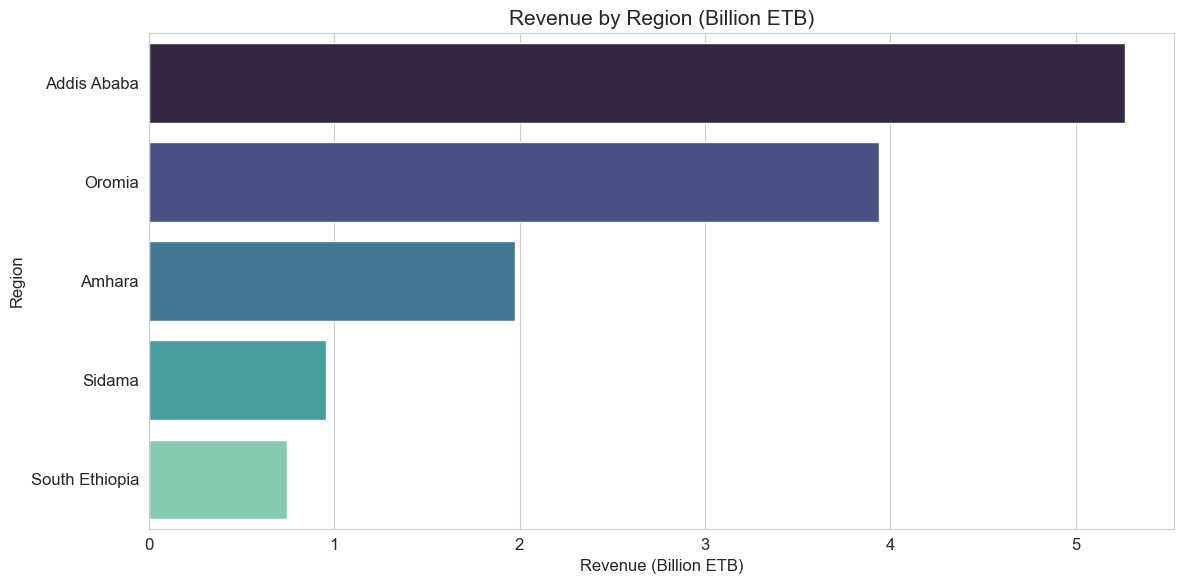

In [12]:
region_rev = df.groupby('Region')['Revenue_ETB'].sum().sort_values(ascending=False).round(0)
region_pct = (region_rev / region_rev.sum() * 100).round(1)

print(pd.concat([region_rev, region_pct], axis=1, keys=['Revenue_ETB', 'Percent']).to_string())

sns.barplot(x=region_rev.values / 1e9, y=region_rev.index, palette='mako')
plt.title('Revenue by Region (Billion ETB)')
plt.xlabel('Revenue (Billion ETB)')
plt.tight_layout()
plt.show()

#### Monthly Revenue & Price



   Order_Date  Revenue_M  Unit_Price_ETB_kg
66 2025-07-31     161.62             277.17
67 2025-08-31     273.33             283.35
68 2025-09-30     243.69             280.04
69 2025-10-31     154.37             284.07
70 2025-11-30     330.43             361.31
71 2025-12-31     200.76             364.33
72 2026-01-31     219.77             401.95
73 2026-02-28     256.98             398.16
74 2026-03-31     228.76             403.67
75 2026-04-30     296.92             399.51
76 2026-05-31     244.80             399.51
77 2026-06-30     216.13             313.44


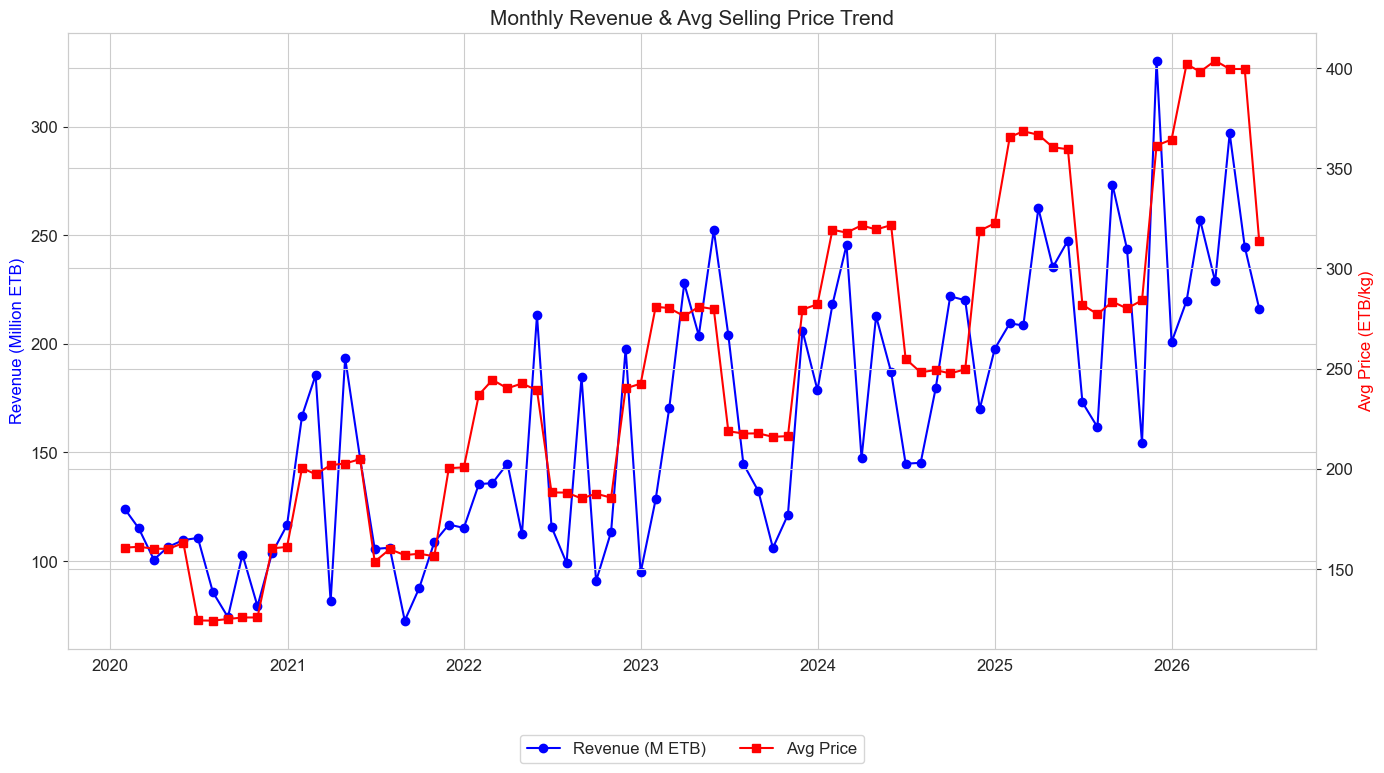

In [13]:
monthly = df.groupby(pd.Grouper(key='Order_Date', freq='ME')).agg({
    'Revenue_ETB': 'sum',
    'Unit_Price_ETB_kg': 'mean'
}).reset_index()

monthly['Revenue_M'] = monthly['Revenue_ETB'] / 1_000_000

print(monthly.tail(12)[['Order_Date', 'Revenue_M', 'Unit_Price_ETB_kg']].round(2))

fig, ax1 = plt.subplots(figsize=(14,7))

ax1.plot(monthly['Order_Date'], monthly['Revenue_M'], 'b-o', label='Revenue (M ETB)')
ax1.set_ylabel('Revenue (Million ETB)', color='b')

ax2 = ax1.twinx()
ax2.plot(monthly['Order_Date'], monthly['Unit_Price_ETB_kg'], 'r-s', label='Avg Price')
ax2.set_ylabel('Avg Price (ETB/kg)', color='r')

plt.title('Monthly Revenue & Avg Selling Price Trend')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Top Products, Regions, Customers



Revenue (ETB) | % of Total
                              Revenue_ETB  Percent
Product                                           
Rebar 16mm Imported (Turkey)   2046090859     15.9
Rebar 6mm G60                  1881413910     14.6
Rebar 8mm G75                  1565274745     12.2
Rebar 12mm G75                 1560400939     12.1
Rebar 10mm G75                 1537326094     11.9
Rebar 14mm G75                 1486501090     11.5
Rebar 20mm G75                 1471351888     11.4
Rebar 16mm G75                 1332501023     10.3


C:\Users\Eldu\AppData\Local\Temp\ipykernel_1392\2889028930.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values / 1e9, y=top_products.index, palette='viridis')


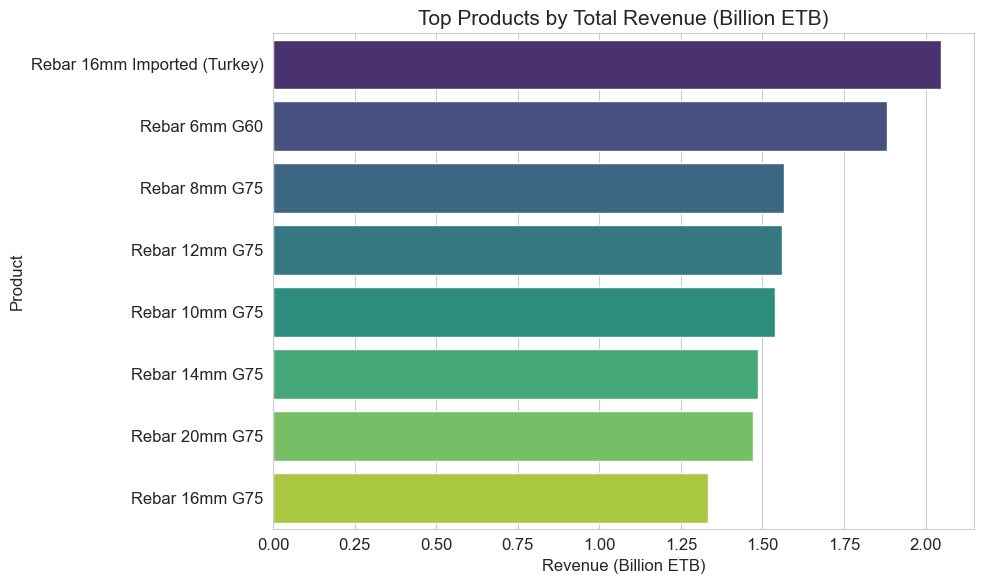

In [14]:
top_products = df.groupby('Product')['Revenue_ETB'].sum().nlargest(10).round(0)
top_products_pct = (top_products / top_products.sum() * 100).round(1)

print("Revenue (ETB) | % of Total")
print(pd.concat([top_products, top_products_pct], axis=1, keys=['Revenue_ETB', 'Percent']).to_string())

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values / 1e9, y=top_products.index, palette='viridis')
plt.title('Top Products by Total Revenue (Billion ETB)')
plt.xlabel('Revenue (Billion ETB)')
plt.tight_layout()
plt.show()

#### Revenue by Customer Type

Type | Revenue (ETB) | % of Total
                    Revenue_ETB  Percent
Customer_Type                           
Large Contractor     2867143153     22.3
Medium Contractor    2582110593     20.0
Government Project   2555363883     19.8
Small Builder        2538492297     19.7
Wholesaler           2337750622     18.1


C:\Users\Eldu\AppData\Local\Temp\ipykernel_1392\3967012225.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_rev.values / 1e9, y=type_rev.index, palette='rocket')


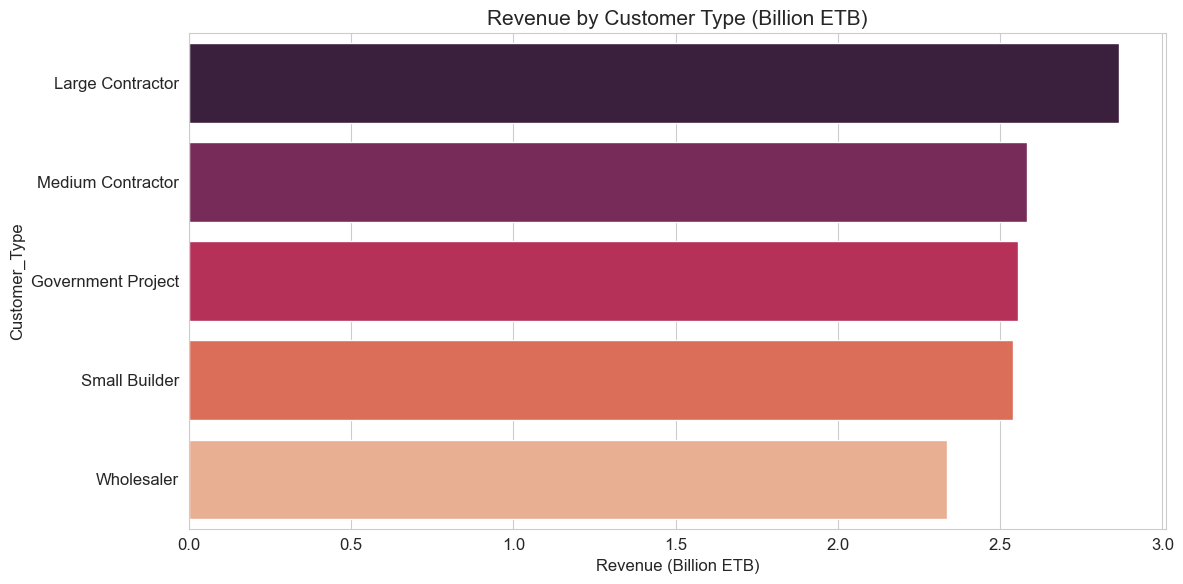

In [15]:
type_rev = df.groupby('Customer_Type')['Revenue_ETB'].sum().sort_values(ascending=False).round(0)
type_pct = (type_rev / type_rev.sum() * 100).round(1)

print("Type | Revenue (ETB) | % of Total")
print(pd.concat([type_rev, type_pct], axis=1, keys=['Revenue_ETB', 'Percent']).to_string())

sns.barplot(x=type_rev.values / 1e9, y=type_rev.index, palette='rocket')
plt.title('Revenue by Customer Type (Billion ETB)')
plt.xlabel('Revenue (Billion ETB)')
plt.tight_layout()
plt.show()

#### Seasonality & Dry vs Wet

In [17]:
season_rev = df.groupby(['Year', 'Season'])['Revenue_ETB'].sum().unstack().fillna(0)
season_pct = season_rev.div(season_rev.sum(axis=1), axis=0) * 100

print("=== Revenue by Year & Season (ETB) ===")
print(season_rev.round(0).to_string())

=== Revenue by Year & Season (ETB) ===
Season         Dry         Wet
Year                          
2020     775739978   452287152
2021    1006106551   480256757
2022    1034057978   603357543
2023    1367507807   708088886
2024    1378360175   911335759
2025    1694390133  1005997632
2026    1247243065   216131132



=== % Split Dry vs Wet per Year ===
Season   Dry   Wet
Year              
2020    63.2  36.8
2021    67.7  32.3
2022    63.2  36.8
2023    65.9  34.1
2024    60.2  39.8
2025    62.7  37.3
2026    85.2  14.8


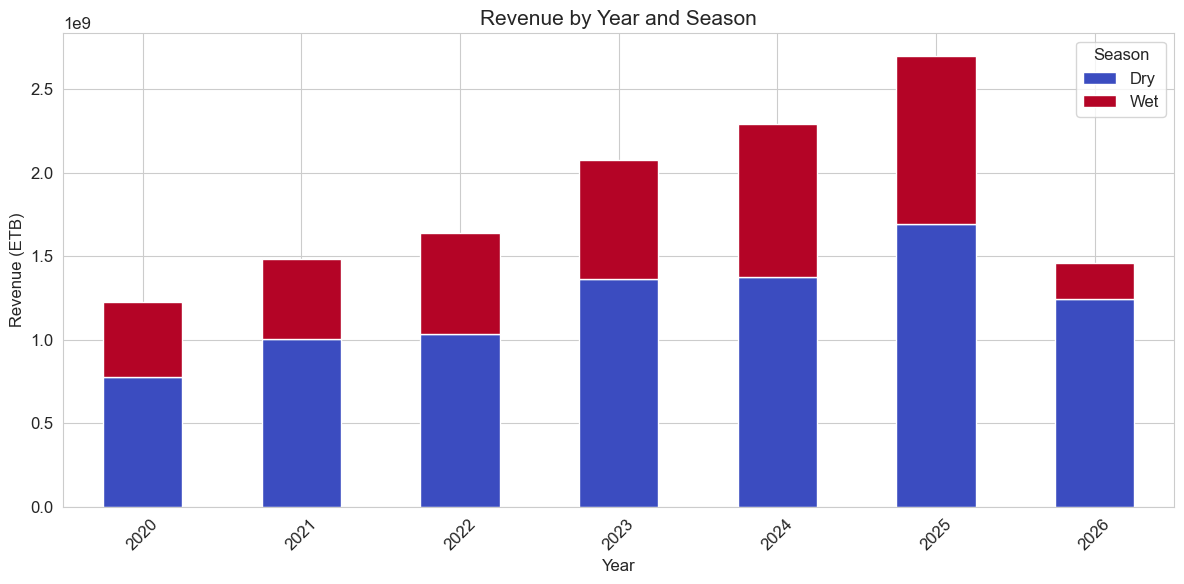

In [18]:
print("\n=== % Split Dry vs Wet per Year ===")
print(season_pct.round(1).to_string())

season_rev.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Revenue by Year and Season')
plt.ylabel('Revenue (ETB)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

#### Price vs Quantity Scatter + Margin by Product



C:\Users\Eldu\AppData\Local\Temp\ipykernel_1392\574014452.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Est_Margin_Pct', y='Product', palette='Set2', ax=axes[1])


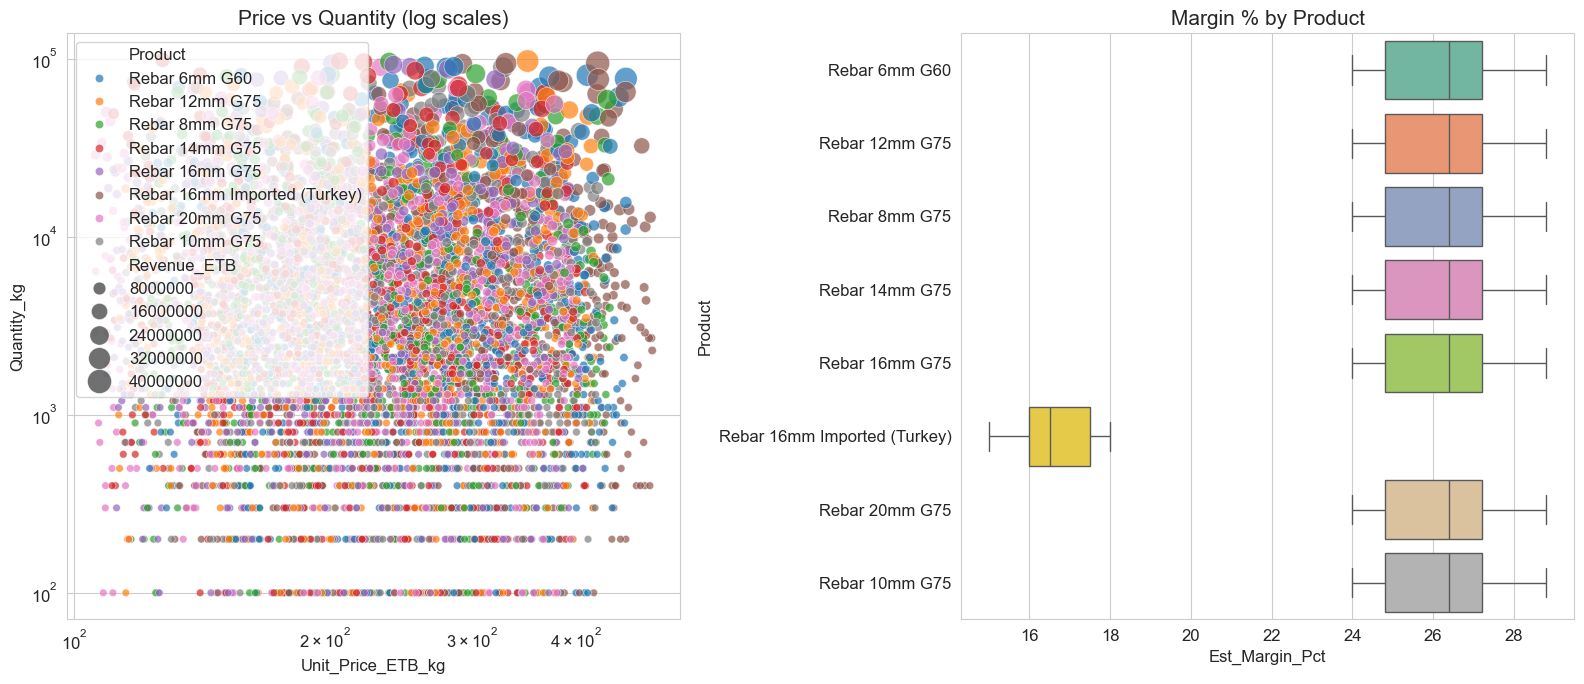


Average Margin % by Product:
Product
Rebar 20mm G75                  26.3
Rebar 6mm G60                   26.3
Rebar 10mm G75                  26.2
Rebar 12mm G75                  26.2
Rebar 8mm G75                   26.2
Rebar 14mm G75                  26.1
Rebar 16mm G75                  26.1
Rebar 16mm Imported (Turkey)    16.6


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter
sns.scatterplot(
    data=df,
    x='Unit_Price_ETB_kg', y='Quantity_kg',
    hue='Product', size='Revenue_ETB',
    sizes=(30, 300), alpha=0.7,
    ax=axes[0]
)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Price vs Quantity (log scales)')

# Boxplot margins
sns.boxplot(data=df, x='Est_Margin_Pct', y='Product', palette='Set2', ax=axes[1])
axes[1].set_title('Margin % by Product')

plt.tight_layout()
plt.show()

print("\nAverage Margin % by Product:")
print(df.groupby('Product')['Est_Margin_Pct'].mean().round(1).sort_values(ascending=False).to_string())

#### KPIs

In [20]:
print(f"Total Revenue:          {df['Revenue_ETB'].sum():,.0f} ETB")
print(f"Avg Unit Price:         {df['Unit_Price_ETB_kg'].mean():.2f} ETB/kg")
print(f"Avg Margin:             {df['Est_Margin_Pct'].mean():.1f}%")
print(f"Top Region Share:       {region_pct.iloc[0]:.1f}% ({region_rev.index[0]})")
print(f"Top Customer Type:      {type_rev.index[0]} ({type_pct.iloc[0]:.1f}%)")
print(f"Dry Season Revenue %:   {season_pct['Dry'].mean():.1f}% (avg across years)")
print("\nTop Product:            " + top_products.index[0] + f" ({top_products_pct.iloc[0]:.1f}%)")

Total Revenue:          12,880,860,548 ETB
Avg Unit Price:         247.10 ETB/kg
Avg Margin:             25.0%
Top Region Share:       40.9% (Addis Ababa)
Top Customer Type:      Large Contractor (22.3%)
Dry Season Revenue %:   66.9% (avg across years)

Top Product:            Rebar 16mm Imported (Turkey) (15.9%)
